<!-- GIVING INTRODUCTION OF THE PROJECT -->
# Introduction
This is a project to predict the severity of traffic accidents in the United States. This is a countrywide car accident dataset that covers 49 states of the USA. The accident data were collected from February 2016 to March 2023, using multiple APIs that provide streaming traffic incident (or event) data. These APIs broadcast traffic data captured by various entities, including the US and state departments of transportation, law enforcement agencies, traffic cameras, and traffic sensors within the road networks. The dataset currently contains approximately 500K accident records.


In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

In [45]:
# Importing Dataset
df = pd.read_csv("Traffic_Accidents.csv")

df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-2047758,Source2,2,2019-06-12 10:10:56,2019-06-12 10:55:58,30.641211,-91.153481,NaN,NaN,0.000,...,False,False,False,False,True,False,Day,Day,Day,Day
1,A-4694324,Source1,2,2022-12-03 23:37:14.000000000,2022-12-04 01:56:53.000000000,38.990562,-77.399070,38.990037,-77.398282,0.056,...,False,False,False,False,False,False,Night,Night,Night,Night
2,A-5006183,Source1,2,2022-08-20 13:13:00.000000000,2022-08-20 15:22:45.000000000,34.661189,-120.492822,34.661189,-120.492442,0.022,...,False,False,False,False,True,False,Day,Day,Day,Day
3,A-4237356,Source1,2,2022-02-21 17:43:04,2022-02-21 19:43:23,43.680592,-92.993317,43.680574,-92.972223,1.054,...,False,False,False,False,False,False,Day,Day,Day,Day
4,A-6690583,Source1,2,2020-12-04 01:46:00,2020-12-04 04:13:09,35.395484,-118.985176,35.395476,-118.985995,0.046,...,False,False,False,False,False,False,Night,Night,Night,Night


# Exploratory Data Analysis

In [3]:
# Exploratory Data Analysis
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     500000 non-null  object 
 1   Source                 500000 non-null  object 
 2   Severity               500000 non-null  int64  
 3   Start_Time             500000 non-null  object 
 4   End_Time               500000 non-null  object 
 5   Start_Lat              500000 non-null  float64
 6   Start_Lng              500000 non-null  float64
 7   End_Lat                279623 non-null  float64
 8   End_Lng                279623 non-null  float64
 9   Distance(mi)           500000 non-null  float64
 10  Description            499999 non-null  object 
 11  Street                 499309 non-null  object 
 12  City                   499981 non-null  object 
 13  County                 500000 non-null  object 
 14  State                  500000 non-nu

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,500000.000000,500000.000000,500000.000000,279623.000000,279623.000000,500000.000000,489534.000000,370983.000000,488870.000000,491072.000000,488709.000000,463013.000000,357384.000000
mean,2.212748,36.206421,-94.736583,36.273192,-95.776553,0.564317,61.646254,58.229028,64.834921,29.536621,9.091540,7.681347,0.008289
std,0.486661,5.071411,17.405761,5.265333,18.120211,1.774872,19.000133,22.352246,22.826158,1.008666,2.708083,5.431361,0.101865
min,1.000000,24.562117,-124.497420,24.570110,-124.497419,0.000000,-77.800000,-53.200000,1.000000,0.120000,0.000000,0.000000,0.000000
25%,2.000000,33.416823,-117.233047,33.474773,-117.778324,0.000000,49.000000,43.000000,48.000000,29.370000,10.000000,4.600000,0.000000
50%,2.000000,35.832147,-87.794365,36.192669,-88.039013,0.029000,64.000000,62.000000,67.000000,29.860000,10.000000,7.000000,0.000000
75%,2.000000,40.082443,-80.359601,40.181341,-80.252449,0.465000,76.000000,75.000000,84.000000,30.030000,10.000000,10.400000,0.000000
max,4.000000,48.999569,-67.484130,48.998901,-67.484130,193.479996,207.000000,207.000000,100.000000,38.440000,130.000000,822.800000,10.130000


### Feature Engineering

In [4]:
# feature engineering
df['Start_Time'] = pd.to_datetime(df['Start_Time'],format='mixed')

df['Hour'] = df['Start_Time'].dt.hour
df['Day'] = df['Start_Time'].dt.day
df['Month'] = df['Start_Time'].dt.month
df['Day_of_Week'] = df['Start_Time'].dt.dayofweek

df['Is_Weekend'] = df['Day_of_Week'].isin([5,6]).astype(int)

df.drop('Start_Time', axis=1, inplace=True)

In [5]:
# handling missing values
df.isnull().sum()

ID                            0
Source                        0
Severity                      0
End_Time                      0
Start_Lat                     0
Start_Lng                     0
End_Lat                  220377
End_Lng                  220377
Distance(mi)                  0
Description                   1
Street                      691
City                         19
County                        0
State                         0
Zipcode                     116
Country                       0
Timezone                    507
Airport_Code               1446
Weather_Timestamp          7674
Temperature(F)            10466
Wind_Chill(F)            129017
Humidity(%)               11130
Pressure(in)               8928
Visibility(mi)            11291
Wind_Direction            11197
Wind_Speed(mph)           36987
Precipitation(in)        142616
Weather_Condition         11101
Amenity                       0
Bump                          0
Crossing                      0
Give_Way

In [6]:
# filling numerical missing values
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [7]:
# filling categorical missing values
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

In [16]:
# encoding categorical features
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [14]:
df.columns

Index(['ID', 'Source', 'Severity', 'End_Time', 'Start_Lat', 'Start_Lng',
       'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City',
       'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code',
       'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
       'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop',
       'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight', 'Hour', 'Day', 'Month', 'Day_of_Week',
       'Is_Weekend'],
      dtype='object')

In [17]:
# checking the effect of columns on severity
for col in df.columns:
    print(col, df[col].corr(df['Severity']))

ID -0.11035035148006198
Source 0.2101798144816484
Severity 1.0
End_Time -0.25170225430498755
Start_Lat 0.06924086093629371
Start_Lng 0.053601583700176654
End_Lat 0.056331999862558185
End_Lng 0.12106450941961398
Distance(mi) 0.03240292504544371
Description 0.022939551650831683
Street 0.07729890841554722
City -0.02807641950333852
County -0.06303581705547677
State 0.0216388524550602
Zipcode -0.045241418781220226
Country nan
Timezone -0.05418642625340645
Airport_Code -0.02311313270198384
Weather_Timestamp -0.24669974843167353
Temperature(F) -0.018363632360046907
Wind_Chill(F) -0.0413522846993643
Humidity(%) 0.019142860570774745
Pressure(in) 0.042595253452456905
Visibility(mi) 0.0005114279166895376
Wind_Direction 0.0269396629148367


d:\Data Analyst\.conda\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\Data Analyst\.conda\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Wind_Speed(mph) 0.03693426215376528
Precipitation(in) 0.010019096249252997
Weather_Condition 0.06312997502788692
Amenity -0.03211364771573769
Bump -0.0029794023067838574
Crossing -0.10822964406889954
Give_Way -0.003866425037044958
Junction 0.05117295278294604
No_Exit -0.008565271542648217
Railway -0.010482739017100602
Roundabout -0.00222911179022388
Station -0.04597939274550337
Stop -0.04777164936485912
Traffic_Calming -0.0044633249405467935
Traffic_Signal -0.10508491835092719
Turning_Loop nan
Sunrise_Sunset 0.009385303392727605
Civil_Twilight 0.009121934676933695
Nautical_Twilight 0.009110409455289787
Astronomical_Twilight 0.006398837771695795
Hour 0.014797698310935987
Day 0.0014448970559826572
Month -0.012258799480921305
Day_of_Week 0.018946755359666223
Is_Weekend 0.029490966048579162


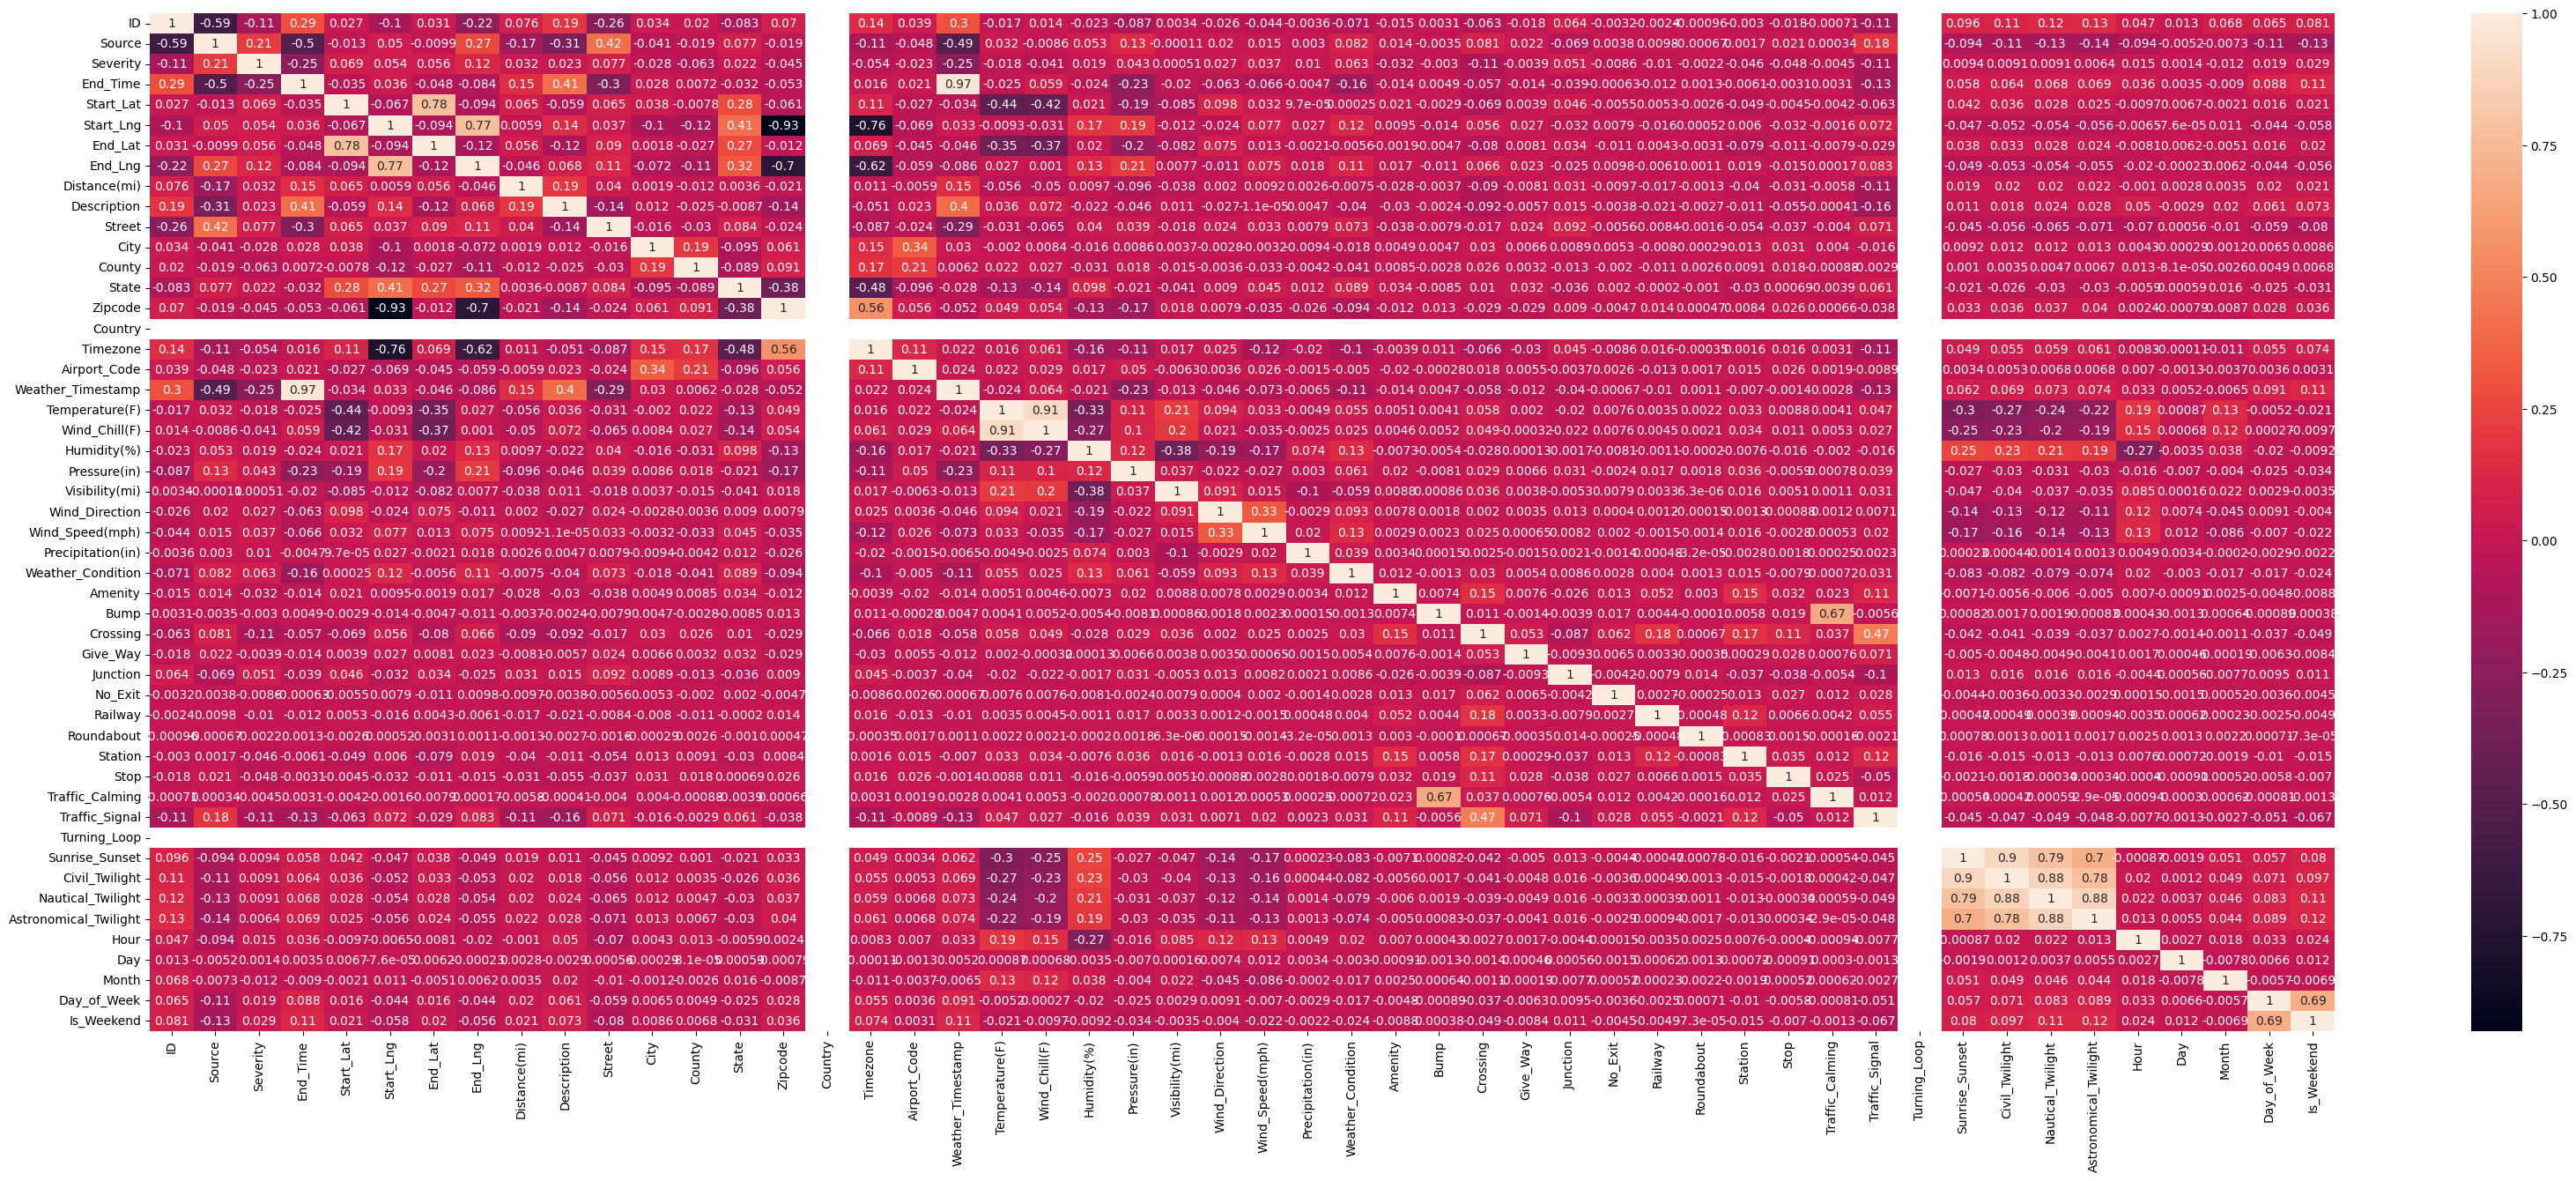

In [18]:
# creating correlation matrix
corr = df.corr()
plt.figure(figsize=[40,15])
sns.heatmap(corr, annot=True)
plt.show()

In [19]:
# chosing columns hows correlation is in two digits
# features = ['Severity', 'Start_Lat', 'Start_Lng', 'Hour', 'Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Junction', 'Traffic_Signal', 'Crossing']
features = [
    'Severity',
    'Start_Lat',
    'Start_Lng',
    'Hour',
    'Day_of_Week',
    'Month',
    'Temperature(F)',
    'Humidity(%)',
    'Visibility(mi)',
    'Wind_Speed(mph)',
    'Precipitation(in)',
    'Junction',
    'Traffic_Signal',
    'Crossing',
    'Sunrise_Sunset'
]
X = df[features]
y = df['Severity'] - 1

# Modelling

In [22]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42
)

### Logistic Regression

In [23]:
# logistic regression
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_lr))

Logistic Regression Accuracy: 0.99904


d:\Data Analyst\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
# classification report
print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       865
           1       1.00      1.00      1.00     79585
           2       1.00      1.00      1.00     16913
           3       1.00      0.98      0.99      2637

    accuracy                           1.00    100000
   macro avg       1.00      0.99      0.99    100000
weighted avg       1.00      1.00      1.00    100000



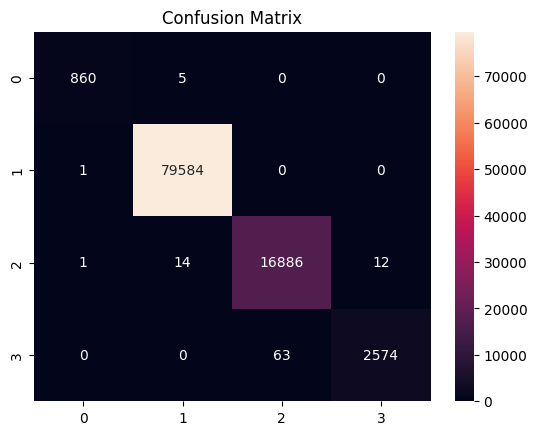

In [25]:
# confusion matrix
cm = confusion_matrix(y_test, pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

### Random Forest

In [26]:
# random forest
rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))

Random Forest Accuracy: 1.0


In [27]:
# classification report
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       865
           1       1.00      1.00      1.00     79585
           2       1.00      1.00      1.00     16913
           3       1.00      1.00      1.00      2637

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000



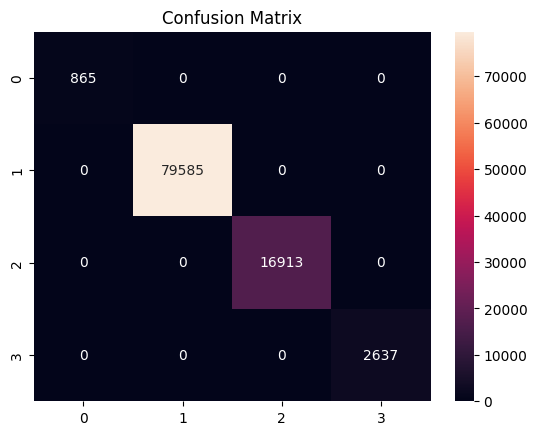

In [28]:
# confusion matrix
cm = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [29]:
# xgboost
xgb = XGBClassifier()

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, pred_xgb))

XGBoost Accuracy: 1.0


In [30]:
# classification report
print(classification_report(y_test, pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       865
           1       1.00      1.00      1.00     79585
           2       1.00      1.00      1.00     16913
           3       1.00      1.00      1.00      2637

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000



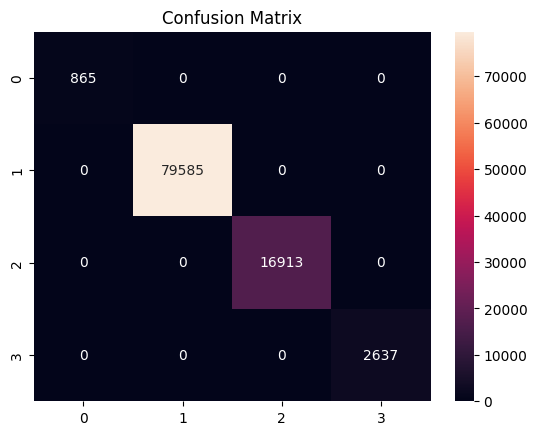

In [31]:
# Confusion Matrix
cm = confusion_matrix(y_test, pred_xgb)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [32]:
# comparing the performance of the models
models = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test, pred_lr), accuracy_score(y_test, pred_rf), accuracy_score(y_test, pred_xgb)],
    'Precision': [precision_score(y_test, pred_lr, average='weighted'), precision_score(y_test, pred_rf, average='weighted'), precision_score(y_test, pred_xgb, average='weighted')],
    'Recall': [recall_score(y_test, pred_lr, average='weighted'), recall_score(y_test, pred_rf, average='weighted'), recall_score(y_test, pred_xgb, average='weighted')],
    'F1 Score': [f1_score(y_test, pred_lr, average='weighted'), f1_score(y_test, pred_rf, average='weighted'), f1_score(y_test, pred_xgb, average='weighted')]
})

models

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.99904,0.999039,0.99904,0.999037
1,Random Forest,1.00000,1.000000,1.00000,1.000000
2,XGBoost,1.00000,1.000000,1.00000,1.000000


# Feature Importance

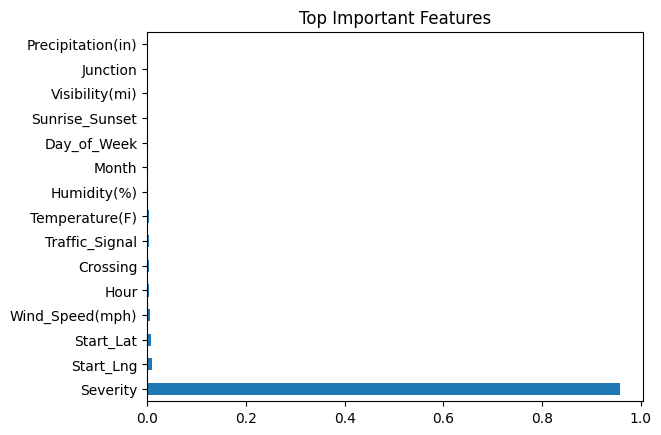

In [33]:
# feature importance
importances = rf.feature_importances_

feat_importance = pd.Series(importances, index=X.columns)

feat_importance.nlargest(15).plot(kind='barh')

plt.title("Top Important Features")
plt.show()

# Data Visualization

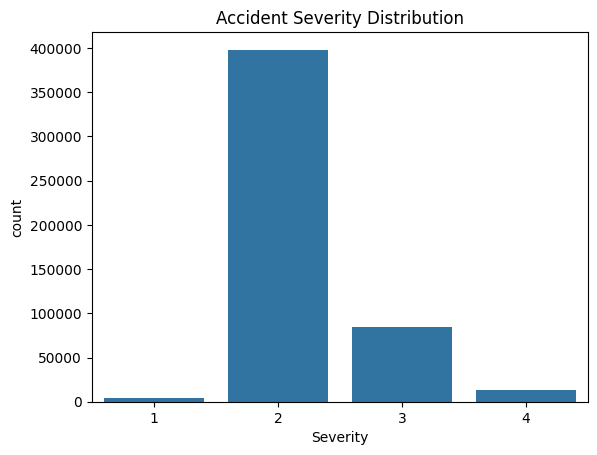

In [34]:
# Plotting the distribution of accident severity
sns.countplot(x='Severity', data=df)
plt.title("Accident Severity Distribution")
plt.show()

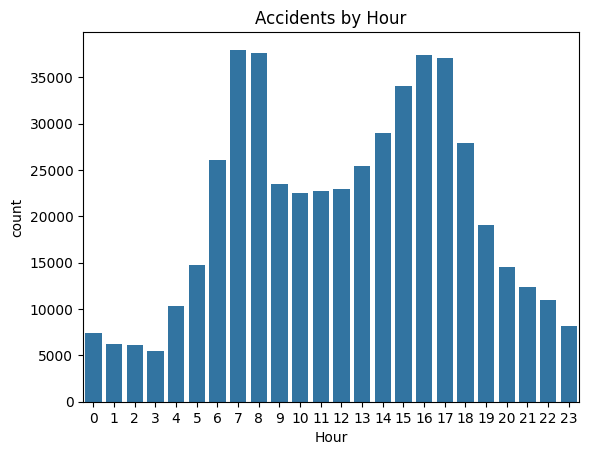

In [35]:
# plotting the distribution of accident severity by hour
sns.countplot(x='Hour', data=df)
plt.title("Accidents by Hour")
plt.show()

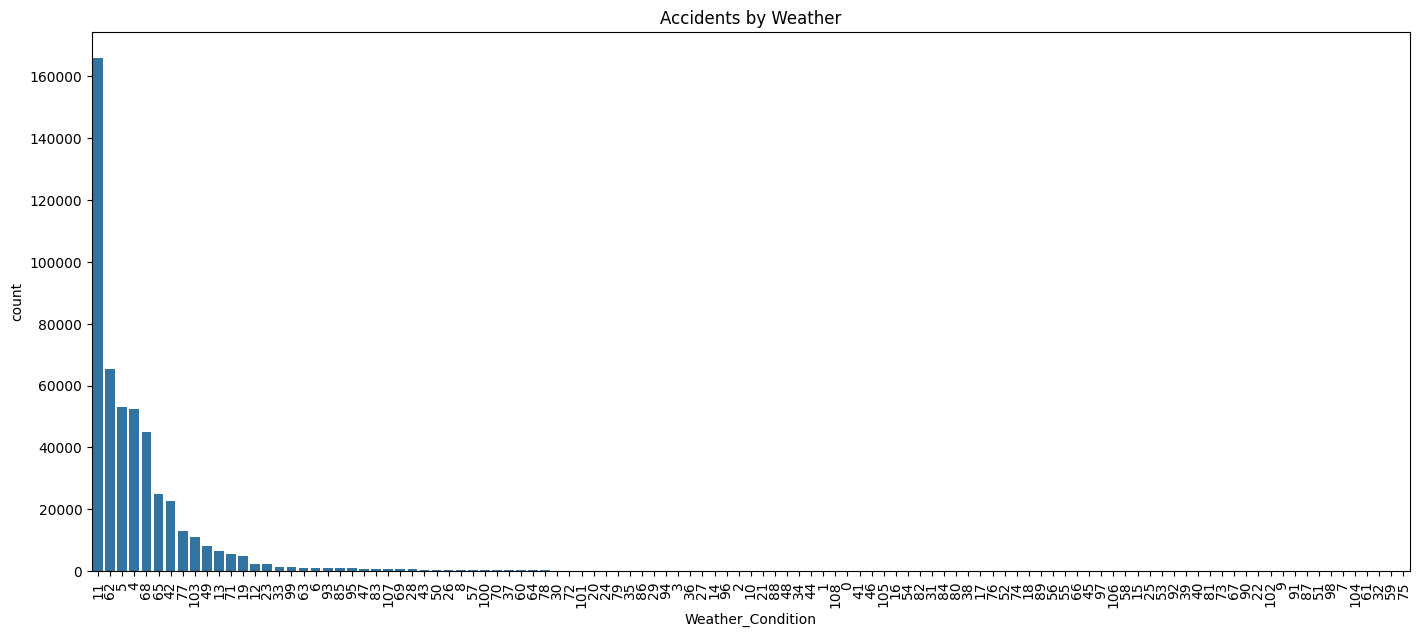

In [36]:
# plotting the distribution of accident severity by weather of figure of size 10,15
plt.figure(figsize=[17,7])
sns.countplot(x='Weather_Condition', data=df, order=df['Weather_Condition'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Accidents by Weather")
plt.show()

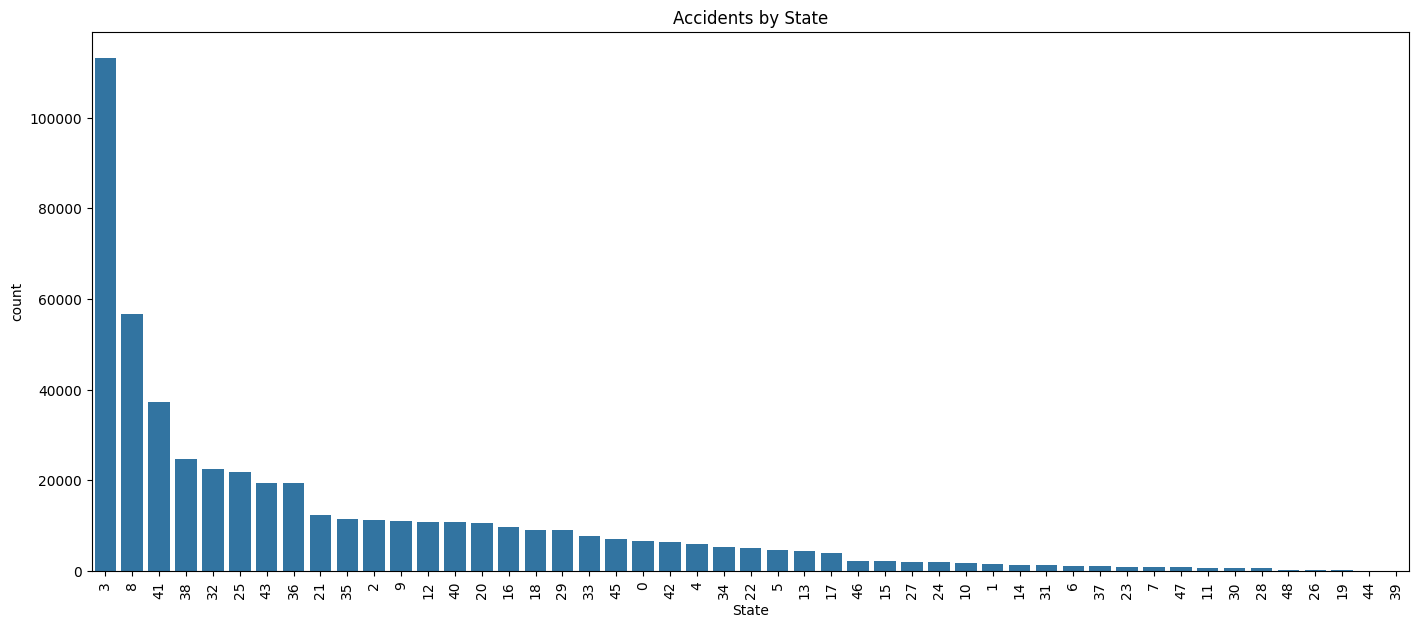

In [37]:
# plotting the distribution of accident by state
plt.figure(figsize=[17,7])
sns.countplot(x='State', data=df, order=df['State'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Accidents by State")
plt.show()

d:\Data Analyst\.conda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


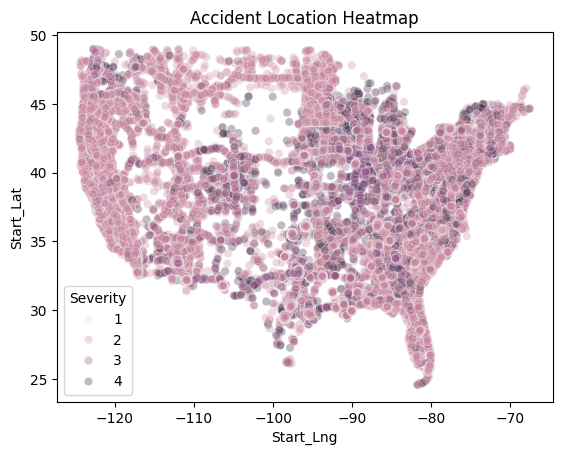

In [38]:
# plotting the distribution of accident severity by Location
sns.scatterplot(
x=df['Start_Lng'],
y=df['Start_Lat'],
hue=df['Severity'],
alpha=0.3
)
plt.title("Accident Location Heatmap")
plt.show()

# Saving the Model

In [ ]:
features = [
    'Start_Lat','Start_Lng','Hour','Day_of_Week','Month',
    'Temperature(F)','Humidity(%)','Visibility(mi)',
    'Wind_Speed(mph)','Precipitation(in)',
    'Junction','Traffic_Signal',
    'Crossing','Sunrise_Sunset'
]

X = df[features]
y = df['Severity'] - 1

from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(X, y)
import pickle
pickle.dump(model, open("model.pkl", "wb"))